In [39]:
import numpy as np
import matplotlib.pyplot as plt
from os import listdir
from os.path import isfile, join
import json
import seaborn as sns

# **Plot 1**

In [93]:
# Experiments Information

d = 8
D = 110
T = 10000
N = 200
delta = 0.05
epsilon = 1e-06

# Smoothing factor
n = 10

In [94]:
def json_parser(path):
    with open(path) as f:
        data = json.load(f)
        return data['cumulative_return']

In [69]:
def running_mean(x, n):
    cumsum = np.cumsum(x, axis=1) 
    return (cumsum[:,n:] - cumsum[:,:-n]) / n

In [70]:
# algo_list = ['UCLK_C', 'UCRL2_VTR(BERNSTEIN)', 'UCRL2(HOEFFDING)']
algo_list = ['UCLK_C', 'UCRL2_VTR(BERNSTEIN)']
colors = sns.color_palette('bright', n_colors=len(algo_list))

In [91]:
R = 0
opt_reward = []
for i in range(T):
    R += 0.63
    opt_reward.append(R)

alg_name:  UCLK_C mean reward:  25789572.1 std:  3057479.4138296153
alg_name:  UCRL2_VTR(BERNSTEIN) mean reward:  25318907.3 std:  4173029.606611845


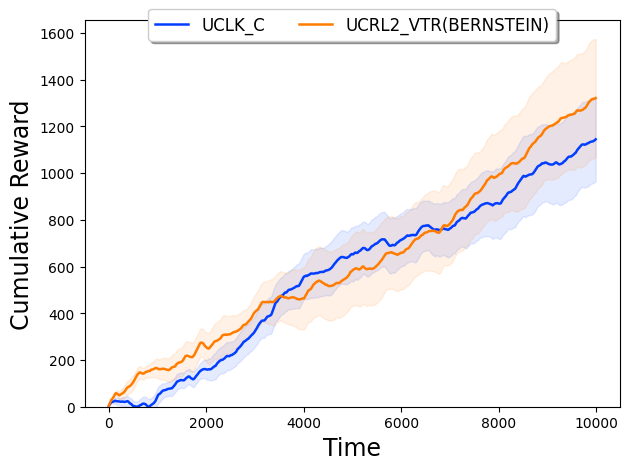

In [92]:
plt.figure()
for i in range(len(algo_list)):
    directory = f"./data/hardtolearn/{algo_list[i]}/regret_d_{d}_D_{D}.00_T_{T}_N_{N}_delta_{delta}_epsilon_{epsilon}/"
    file_list = [f for f in listdir(directory) if isfile(join(directory, f))]
    if '.DS_Store' in file_list:
        file_list.remove('.DS_Store')
    if '.ipynb_checkpoints' in file_list:
        file_list.remove('.ipynb_checkpoints')

    algo_returns = []
    for j in range(len(file_list)):
        r = json_parser(directory + file_list[j])
        algo_returns.append(r)

    data_mean = np.mean(running_mean(np.array(opt_reward) - algo_returns, n), axis=0)
    data_std = np.std(running_mean(np.array(opt_reward) - algo_returns, n), axis=0)    
    
    timestep = np.arange(len(data_mean))

    plt.rc('font', size=10)        # 기본 폰트 크기
    plt.rc('axes', labelsize=17)   # x,y축 label 폰트 크기
    plt.rc('xtick', labelsize=10)  # x축 눈금 폰트 크기 
    plt.rc('ytick', labelsize=10)  # y축 눈금 폰트 크기
    plt.rc('legend', fontsize=12)  # 범례 폰트 크기
    # plt.rc('figure', titlesize=50) # figure title 폰트 크기

    plt.fill_between(timestep, data_mean + 0.3 * data_std, data_mean - 0.3 * data_std, alpha=0.1, edgecolor=colors[i], facecolor=colors[i])
    plt.plot(timestep, data_mean, color=colors[i], linewidth=1.8, label=algo_list[i])
    
    print("alg_name: ", algo_list[i], "mean reward: ", np.mean(np.sum(algo_returns, axis=1)),
          "std: ", np.std(np.sum(algo_returns, axis=1)))
    
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.05), fancybox=True, shadow=True, ncol=3)
plt.xlabel("Time")
plt.ylabel("Cumulative Reward")
plt.ylim(0)
plt.tight_layout()
plt.savefig(f'(Hard-to-learn, Rewards)_regret_d_{d}_D_{D}_T_{T}_N_{N}_delta_{delta}_epsilon_{epsilon}' + '.pdf', dpi=300)  # format.pdf
plt.show()

# **Plot 2**

In [122]:
# Experiments Information

d = 8
D = 100
T = 10000
N = 200
delta = 0.05
epsilon = 1e-06

# Smoothing factor
n = 10

In [123]:
def json_parser(path):
    with open(path) as f:
        data = json.load(f)
        return data['cumulative_regret']

In [124]:
def running_mean(x, n):
    cumsum = np.cumsum(x, axis=1) 
    return (cumsum[:,n:] - cumsum[:,:-n]) / n

In [125]:
# algo_list = ['UCLK_C', 'UCRL2_VTR(BERNSTEIN)', 'UCRL2(HOEFFDING)']
algo_list = ['UCLK_C', 'UCRL2_VTR(BERNSTEIN)']
colors = sns.color_palette('bright', n_colors=len(algo_list))

alg_name:  UCLK_C mean reward:  9240828.4 std:  4124592.4799790154
alg_name:  UCRL2_VTR(BERNSTEIN) mean reward:  6773965.6 std:  3715337.544082508


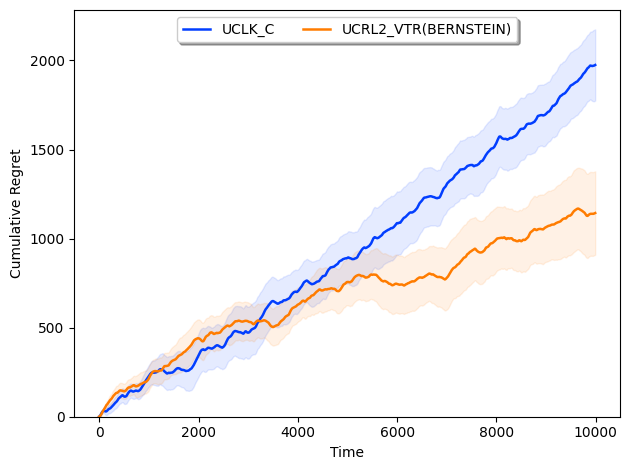

In [126]:
plt.figure()
for i in range(len(algo_list)):
    directory = f"./data/hardtolearn/{algo_list[i]}/regret_d_{d}_D_{D}.00_T_{T}_N_{N}_delta_{delta}_epsilon_{epsilon}/"
    file_list = [f for f in listdir(directory) if isfile(join(directory, f))]
    if '.DS_Store' in file_list:
        file_list.remove('.DS_Store')
    if '.ipynb_checkpoints' in file_list:
        file_list.remove('.ipynb_checkpoints')

    algo_returns = []
    for j in range(len(file_list)):
        r = json_parser(directory + file_list[j])
        algo_returns.append(r)

    data_mean = np.mean(running_mean(algo_returns, n), axis=0)
    data_std = np.std(running_mean(algo_returns, n), axis=0)    
    
    timestep = np.arange(len(data_mean))

    plt.rc('font', size=10)        # 기본 폰트 크기
    plt.rc('axes', labelsize=10)   # x,y축 label 폰트 크기
    plt.rc('xtick', labelsize=10)  # x축 눈금 폰트 크기 
    plt.rc('ytick', labelsize=10)  # y축 눈금 폰트 크기
    plt.rc('legend', fontsize=10)  # 범례 폰트 크기
    # plt.rc('figure', titlesize=50) # figure title 폰트 크기

    plt.fill_between(timestep, data_mean + 0.3 * data_std, data_mean - 0.3 * data_std, alpha=0.1, edgecolor=colors[i], facecolor=colors[i])
    plt.plot(timestep, data_mean, color=colors[i], linewidth=1.8, label=algo_list[i])
    
    print("alg_name: ", algo_list[i], "mean reward: ", np.mean(np.sum(algo_returns, axis=1)),
          "std: ", np.std(np.sum(algo_returns, axis=1)))
    
handles, labels = plt.gca().get_legend_handles_labels()
# loc: 'best', 'upper right', 'upper left', 'lower left', 'lower right', 'right', 'center left', 'center right', 'lower center', 'upper center', 'center'
# plt.legend(handles, labels, loc='center', bbox_to_anchor=(0.5, 1.05), fancybox=True, shadow=True, ncol=3)
plt.legend(handles, labels, loc='upper center', fancybox=True, shadow=True, ncol=3)
plt.xlabel("Time")
plt.ylabel("Cumulative Regret")
plt.ylim(0)
plt.tight_layout()
plt.savefig(f'(Hard-to-learn, Rewards)_regret_d_{d}_D_{D}_T_{T}_N_{N}_delta_{delta}_epsilon_{epsilon}' + '.pdf', dpi=300)  # format.pdf
plt.show()